# Eksplorasi Data MIT-BIH Atrial Fibrillation Database (AFDB)

Notebook ini dirancang untuk membaca, memproses, dan memvisualisasikan sinyal ECG beserta anotasinya menggunakan library `wfdb`.

In [1]:
# Langkah 1: Install library yang dibutuhkan jika belum terinstall
# !pip install wfdb matplotlib numpy pandas scipy

In [2]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Tentukan path ke record yang akan dibaca (misalnya record '04015')
# Catatan: wfdb tidak memerlukan ekstensi file (.dat atau .hea)
record_path = 'files/04015'

try:
    # 1. Membaca data sinyal dan header
    record = wfdb.rdrecord(record_path)
    print("=== INFORMASI RECORD ===")
    print(f"Nama Record          : {record.record_name}")
    print(f"Frekuensi Sampling   : {record.fs} Hz")
    print(f"Jumlah Sinyal/Kanal   : {record.n_sig}")
    print(f"Nama Sinyal          : {record.sig_name}")
    print(f"Ukuran Data Sinyal   : {record.p_signal.shape} (baris/sample, kolom/channel)")
    print(f"Durasi Sinyal (detik): {record.sig_len / record.fs:.2f} detik (~{record.sig_len / (record.fs * 3600):.2f} jam)")

    # 2. Membaca anotasi beat/detak jantung (.qrs)
    try:
        beat_ann = wfdb.rdann(record_path, 'qrs')
        print(f"\n=== ANOTASI BEAT (.qrs) ===")
        print(f"Jumlah detak terdeteksi: {len(beat_ann.sample)}")
        print(f"Contoh lokasi sample   : {beat_ann.sample[:5]}")
        print(f"Contoh simbol anotasi  : {beat_ann.symbol[:5]}")
    except Exception as e:
        print(f"\nAnotasi beat (.qrs) tidak dapat dimuat: {e}")

    # 3. Membaca anotasi rhythm/ritme jantung (.atr)
    try:
        rhythm_ann = wfdb.rdann(record_path, 'atr')
        print(f"\n=== ANOTASI RHYTHM (.atr) ===")
        print(f"Jumlah perubahan ritme : {len(rhythm_ann.sample)}")
        print(f"Contoh lokasi sample   : {rhythm_ann.sample[:5]}")
        # aux_note berisi informasi ritme seperti '(N' (normal) atau '(AFIB' (atrial fibrillation)
        print(f"Contoh label ritme     : {rhythm_ann.aux_note[:5]}")
    except Exception as e:
        print(f"\nAnotasi rhythm (.atr) tidak dapat dimuat: {e}")

except Exception as e:
    print(f"Gagal membaca record: {e}")

=== INFORMASI RECORD ===
Nama Record          : 04015
Frekuensi Sampling   : 250 Hz
Jumlah Sinyal/Kanal   : 2
Nama Sinyal          : ['ECG1', 'ECG2']
Ukuran Data Sinyal   : (9205760, 2) (baris/sample, kolom/channel)
Durasi Sinyal (detik): 36823.04 detik (~10.23 jam)

=== ANOTASI BEAT (.qrs) ===
Jumlah detak terdeteksi: 44005
Contoh lokasi sample   : [ 61 200 358 584 729]
Contoh simbol anotasi  : ['N', 'N', 'N', 'N', 'N']

=== ANOTASI RHYTHM (.atr) ===
Jumlah perubahan ritme : 15
Contoh lokasi sample   : [    30 102584 119604 121773 122194]
Contoh label ritme     : ['(N', '(AFIB', '(N', '(AFIB', '(N']


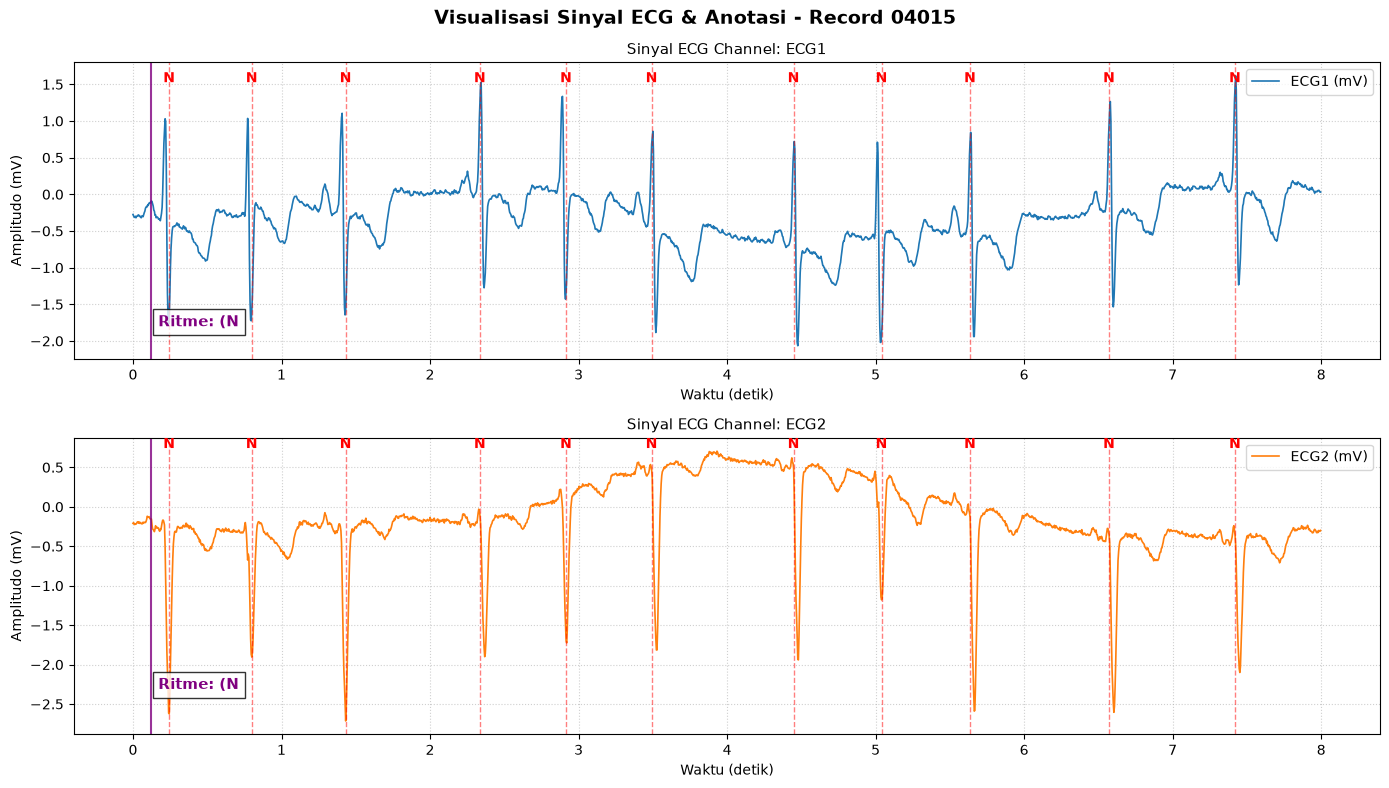

In [3]:
# Visualisasi Sinyal ECG
seconds_to_plot = 8  # Durasi visualisasi dalam detik
fs = record.fs
n_samples = int(seconds_to_plot * fs)

# Membuat sumbu waktu dalam detik
time_axis = np.arange(n_samples) / fs

plt.figure(figsize=(14, 8))

for channel_idx in range(record.n_sig):
    plt.subplot(record.n_sig, 1, channel_idx + 1)
    
    # Plot sinyal ECG
    plt.plot(time_axis, record.p_signal[:n_samples, channel_idx], 
             label=f"{record.sig_name[channel_idx]} ({record.units[channel_idx]})", 
             color='#1f77b4' if channel_idx == 0 else '#ff7f0e', 
             linewidth=1.2)
    
    # Tandai lokasi detak jantung (QRS) jika berada dalam jangkauan plot
    if 'beat_ann' in locals():
        in_range_mask = beat_ann.sample < n_samples
        plt_samples = beat_ann.sample[in_range_mask]
        plt_symbols = np.array(beat_ann.symbol)[in_range_mask]
        
        # Menggambar garis vertikal merah untuk setiap detak terdeteksi
        for idx, (sample, symbol) in enumerate(zip(plt_samples, plt_symbols)):
            t_sec = sample / fs
            plt.axvline(x=t_sec, color='red', linestyle='--', alpha=0.5, linewidth=1)
            # Menampilkan simbol anotasi di bagian atas plot
            plt.text(t_sec, plt.gca().get_ylim()[1] * 0.85, symbol, 
                     color='red', fontsize=10, weight='bold', horizontalalignment='center')
            
    # Menampilkan ritme awal
    if 'rhythm_ann' in locals() and len(rhythm_ann.sample) > 0:
        # Mencari ritme aktif saat t = 0
        active_rhythm = rhythm_ann.aux_note[0]
        # Mencari jika ada perubahan ritme dalam jangkauan plot
        in_range_rhythm_mask = rhythm_ann.sample < n_samples
        rhythm_samples = rhythm_ann.sample[in_range_rhythm_mask]
        rhythm_notes = np.array(rhythm_ann.aux_note)[in_range_rhythm_mask]
        
        for r_sample, r_note in zip(rhythm_samples, rhythm_notes):
            r_t = r_sample / fs
            plt.axvline(x=r_t, color='purple', linestyle='-', alpha=0.8, linewidth=1.5)
            plt.text(r_t + 0.05, plt.gca().get_ylim()[0] * 0.8, f"Ritme: {r_note}", 
                     color='purple', fontsize=11, weight='bold', bbox=dict(facecolor='white', alpha=0.8))
            
    plt.title(f"Sinyal ECG Channel: {record.sig_name[channel_idx]}", fontsize=11)
    plt.ylabel(f"Amplitudo ({record.units[channel_idx]})", fontsize=10)
    plt.xlabel("Waktu (detik)", fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')

plt.suptitle(f"Visualisasi Sinyal ECG & Anotasi - Record {record.record_name}", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

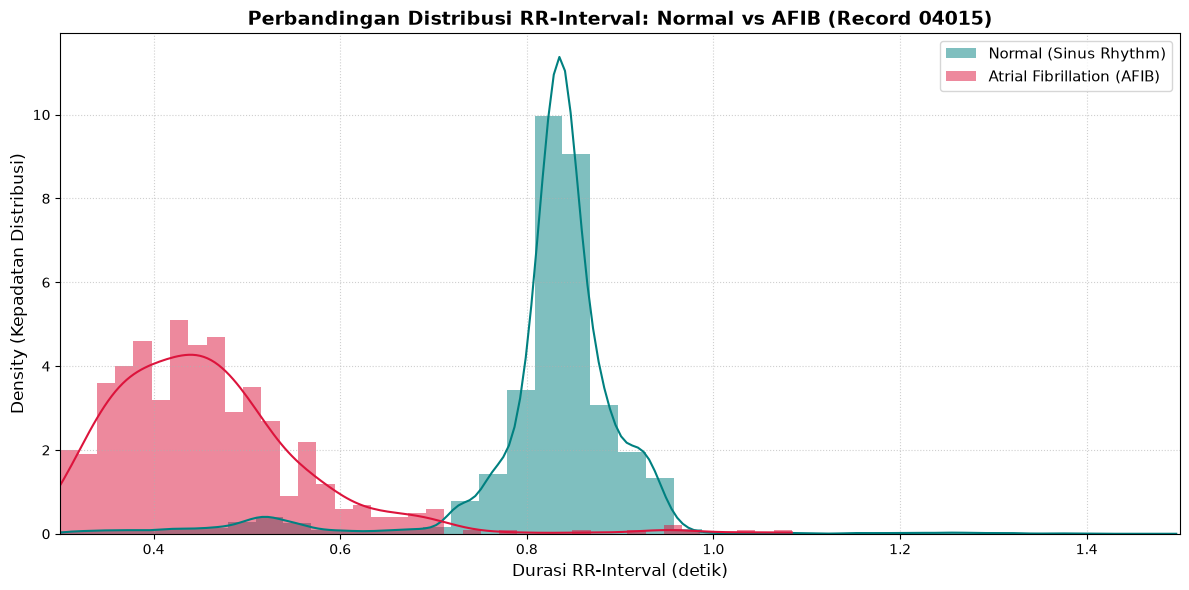

=== STATISTIK RR-INTERVAL ===
          count      mean       std  min    25%    50%    75%    max
Rhythm                                                              
AFIB      511.0  0.457542  0.107114  0.3  0.384  0.444  0.504  1.084
N       43332.0  0.824146  0.096637  0.3  0.812  0.836  0.860  1.496


In [4]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
record_path = 'files/04015'
beat_ann = wfdb.rdann(record_path, 'qrs')     # Lokasi puncak R
rhythm_ann = wfdb.rdann(record_path, 'atr')   # Label ritme (Normal vs AFIB)
fs = beat_ann.fs

# 2. Hitung RR-Interval awal (dalam detik)
r_peaks = beat_ann.sample
rr_intervals = np.diff(r_peaks) / fs

# Kita pasangkan setiap RR-interval dengan indeks sampel mulainya
rr_start_samples = r_peaks[:-1]

# 3. Labeling setiap RR-Interval secara dinamis
# Mencari ritme aktif untuk setiap sampel awal RR-interval
rhythm_change_samples = rhythm_ann.sample
rhythm_labels = rhythm_ann.aux_note

# Menggunakan np.searchsorted untuk memetakan setiap RR ke ritme yang sedang aktif
# searchsorted mencari di index mana sampel RR berada di antara titik perubahan ritme
rhythm_indices = np.searchsorted(rhythm_change_samples, rr_start_samples) - 1
# Menjaga agar tidak ada index di luar batas (misal -1 didefinisikan ke index 0)
rhythm_indices = np.clip(rhythm_indices, 0, len(rhythm_labels) - 1)

# Ambil label teks (misal '(N' atau '(AFIB') untuk setiap RR-interval
rr_labels = np.array([rhythm_labels[idx] for idx in rhythm_indices])

# Buat DataFrame untuk mempermudah analisis
df_rr = pd.DataFrame({
    'RR_Interval': rr_intervals,
    'Rhythm': rr_labels
})

# Bersihkan nama label (menghilangkan tanda kurung buka)
df_rr['Rhythm'] = df_rr['Rhythm'].str.replace('(', '', regex=False)

# 4. Preprocessing: Membuang Outlier/Artifact ekstrem (0.3s - 1.5s)
# Langkah ini penting agar visualisasi distribusi tidak terdistorsi oleh derau
df_rr_clean = df_rr[(df_rr['RR_Interval'] >= 0.3) & (df_rr['RR_Interval'] <= 1.5)]

# Filter data untuk kelas Normal (N) dan AFIB (AFIB)
normal_rr = df_rr_clean[df_rr_clean['Rhythm'] == 'N']['RR_Interval']
afib_rr = df_rr_clean[df_rr_clean['Rhythm'] == 'AFIB']['RR_Interval']

# 5. Plotting Perbandingan Distribusi
plt.figure(figsize=(12, 6))

# Histogram + KDE (Kernel Density Estimate) untuk kelas Normal
sns.histplot(normal_rr, kde=True, color='teal', label='Normal (Sinus Rhythm)', 
             stat='density', alpha=0.5, bins=40, edgecolor='none')

# Histogram + KDE untuk kelas AFIB
sns.histplot(afib_rr, kde=True, color='crimson', label='Atrial Fibrillation (AFIB)', 
             stat='density', alpha=0.5, bins=40, edgecolor='none')

plt.title(f'Perbandingan Distribusi RR-Interval: Normal vs AFIB (Record {beat_ann.record_name})', 
          fontsize=14, weight='bold')
plt.xlabel('Durasi RR-Interval (detik)', fontsize=12)
plt.ylabel('Density (Kepadatan Distribusi)', fontsize=12)
plt.xlim(0.3, 1.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# 6. Tampilkan Statistik Ringkas
print("=== STATISTIK RR-INTERVAL ===")
print(df_rr_clean.groupby('Rhythm')['RR_Interval'].describe())

## Distribusi Data & Rentang Fitur HRV

Cell di bawah ini membaca dataset akhir yang berisi 10.713 baris data dan melihat rentang distribusi (min, max, rata-rata) serta visualisasi distribusinya untuk mendeteksi *outliers* atau perbedaan antara pasien Normal dan AFIB.

=== RENTANG DISTRIBUSI STATISTIK KESELURUHAN ===


,min,25%,50%,mean,75%,max
Mean_RR,0.351720,0.589880,0.703360,0.729742,0.875360,1.198360
SDNN,0.003081,0.019585,0.046656,0.052245,0.079029,0.426859
RMSSD,0.003793,0.018242,0.053312,0.052625,0.077959,0.633117
pNN50,0.000000,1.010101,26.262626,26.214445,47.474747,100.000000
CV,0.005103,0.023795,0.072545,0.077792,0.121378,0.403748
SD1,0.002695,0.012958,0.037889,0.037395,0.055392,0.449938
SD2,0.003235,0.022540,0.050670,0.062259,0.094804,0.587649
SD1_SD2_ratio,0.044049,0.476799,0.624589,0.683148,0.824392,54.272056
SampEn,0.000000,1.314321,1.648659,1.655248,1.989585,4.110874
Label,0.000000,0.000000,0.000000,0.453468,1.000000,1.000000



=== RATA-RATA FITUR: NORMAL vs AFIB ===


,Mean_RR,SDNN,RMSSD,pNN50,CV,SD1,SD2,SD1_SD2_ratio,SampEn,Patient
Label,,,,,,,,,,
0,0.810872,0.029297,0.030636,8.928223,0.037186,0.021769,0.033457,0.727996,1.594834,6003.720410
1,0.631963,0.079903,0.079126,47.048293,0.126731,0.056228,0.096972,0.629096,1.728060,7037.286332


/tmp/ipykernel_215779/1232691257.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hrv, x="Label", y=fitur, palette=["teal", "crimson"])
/tmp/ipykernel_215779/1232691257.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hrv, x="Label", y=fitur, palette=["teal", "crimson"])
/tmp/ipykernel_215779/1232691257.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hrv, x="Label", y=fitur, palette=["teal", "crimson"])
/tmp/ipykernel_215779/1232691257.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is d

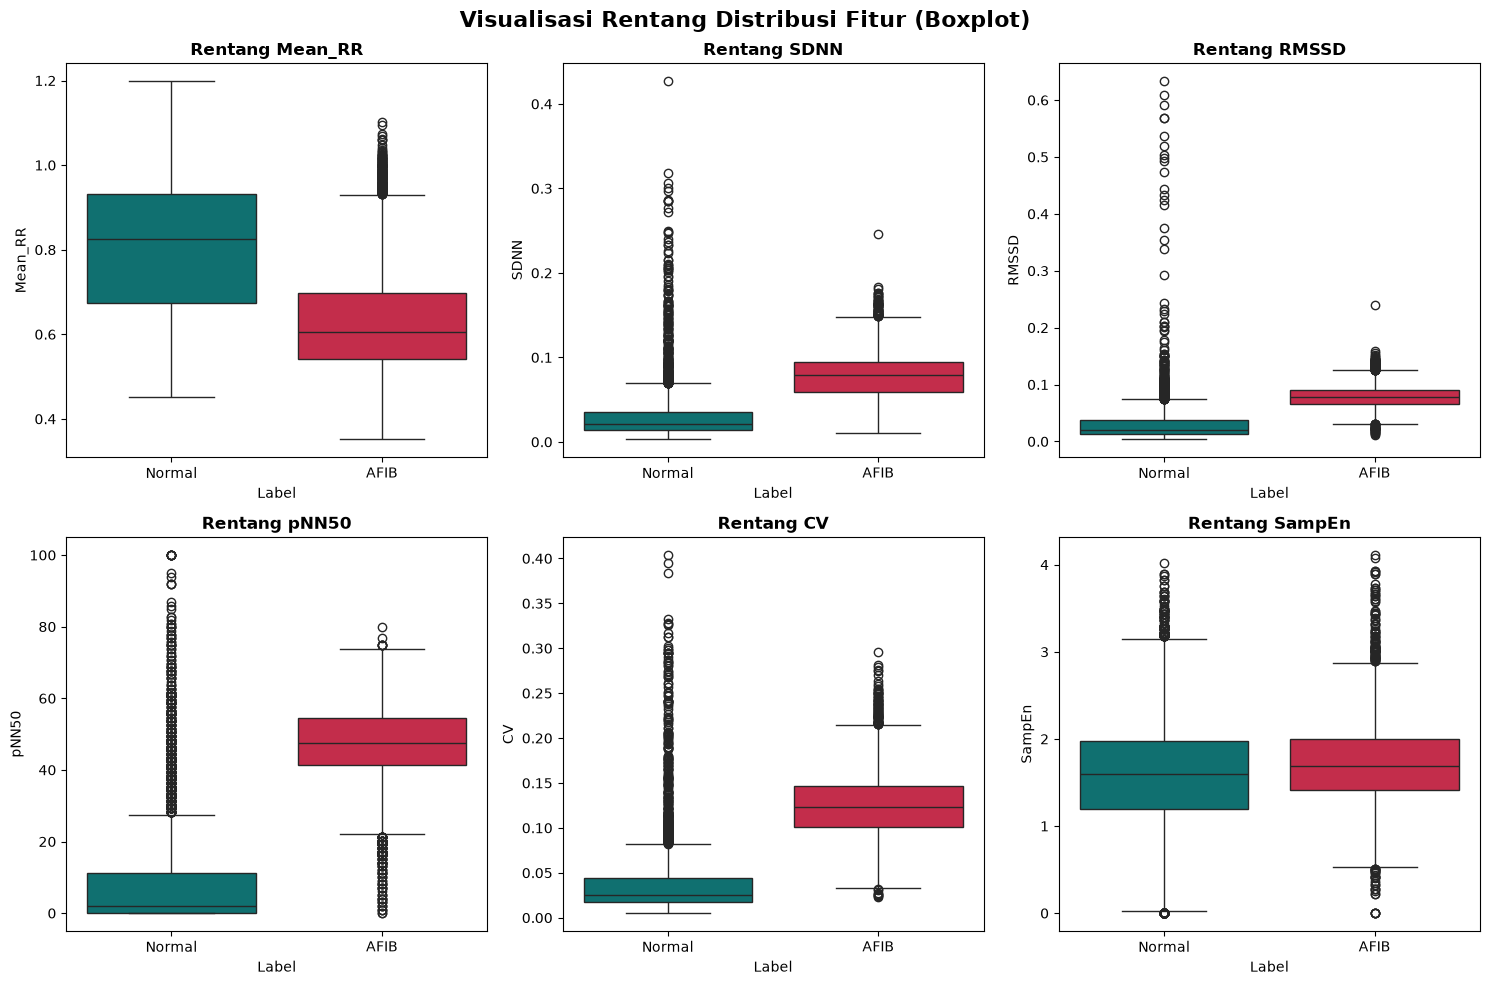

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset hasil ekstraksi HRV
df_hrv = pd.read_csv("hrv_features_dataset.csv")

# 2. Tampilkan rentang distribusi statistik (Min, Max, Rata-rata)
print("=== RENTANG DISTRIBUSI STATISTIK KESELURUHAN ===")
display(df_hrv.describe().T[["min", "25%", "50%", "mean", "75%", "max"]])

# Tampilkan statistik spesifik per kelas Normal (0) dan AFIB (1)
print("\n=== RATA-RATA FITUR: NORMAL vs AFIB ===")
display(df_hrv.groupby("Label").mean())

# 3. Visualisasi Distribusi (Boxplot) untuk melihat rentang dan sebaran data
plt.figure(figsize=(15, 10))
fitur_kunci = ["Mean_RR", "SDNN", "RMSSD", "pNN50", "CV", "SampEn"]

for i, fitur in enumerate(fitur_kunci, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df_hrv, x="Label", y=fitur, palette=["teal", "crimson"])
    plt.title(f"Rentang {fitur}", fontsize=12, weight="bold")
    plt.xticks([0, 1], ["Normal", "AFIB"])

plt.suptitle("Visualisasi Rentang Distribusi Fitur (Boxplot)", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()